# 四、三生万物

### 基本门电路

| 门   | 唯物辩证法 |
| ---- | ---------- |
| 与   | 整体       |
| 或   | 部分     |
| 非   | 对立/否定       |
| 异或   | 发展/矛盾转化       |

### 异或门电路

异或门（XOR gate）的输出在输入不同时为真，输入相同时为假。使用基本门电路（与门、或门、非门）实现异或功能的方法如下：



对于两个输入 A 和 B，异或输出 Y 的逻辑表达式为：

$$Y = A \oplus B = (A \cdot \overline{B}) + (\overline{A} \cdot B) \ $$

所需基本门电路：

- 2 个非门（NOT gate）
- 2 个与门（AND gate）
- 1 个或门（OR gate）


## 1. 升维

### 1. 从“数”到“运算”的自由度变化
**单个数（如“5”）：0个自由度** 
单个数是一个固定值，没有任何可以独立变化的变量。它在数学上对应“数轴上的一个点”，属于0维空间，因此自由度为0（并非“无自由度”，而是自由度为0）。

**两个数的加法（如“a+b”）：1个自由度** 
加法中，a,b两个数沿数轴线性移动。对应“数轴上的一条线”，属于1维空间，因此自由度为1。

**两个数的乘法（如“a×b”）：2个自由度** 
乘法中，a和b可以独立变化（比如a从1变到2，b从3变到4，两者互不影响），结果（a×b）会对应平面直角坐标系中的一个点（a为x轴，b为y轴）。此时有2个独立变量，对应“平面”，属于2维空间，因此自由度为2。



### 2. 加法是标量的积分


比如计算线段长度（标量）时，积分表达式是\(\int_{0}^{a} dx = a\)，这可以看作“1的a次累加”（即1+1+…+1，共a次），本质就是加法的极限形式。

### 3. 乘法是加法的积分

在平面直角坐标系中，点$(0,0)$与另一点$(a,b)$（假设$a>0, b>0$）形成的矩形区域$R$可以表示为：$0 ≤ x ≤ a, 0 ≤ y ≤ b$。该矩形的面积可以通过二重积分计算。

若先对x积分再对y积分，二重积分表示为：

$$
\text{S} = \int_{y=0}^{b} \int_{x=0}^{a} \, dx \, dy
$$

计算过程如下：
- 先计算内层积分：\(\int_{x=0}^{a} \, dx = a\)
- 然后计算外层积分：\(\int_{y=0}^{b} a \, dy = a \cdot b\)

因此，面积为 \(a \cdot b\)，与预期一致。



## 2. 异或型数据分类

| 输入 $x_1$ | 输入 $x_2$ | $x_1$ XOR $x_2$ |
| ---------- | ---------- | --------------- |
| -1         | -1         | -1              |
| -1         | 1          | 1               |
| 1          | -1         | 1               |
| 1          | 1          | -1              |

### 1.2 基础逻辑门实现异或运算

#### 1. 基础逻辑门真值表

在这里我们使用-1表示False，1表示True。下面是这四种逻辑运算在这种表示下的真值表。

---
**非运算（NOT）**

| 输入 $x$ | NOT $x$ |
|-------|-----------|
| -1    | 1         |
| 1     | -1        |

---

**与运算（AND）**

| 输入 $x_1$ | 输入 $x_2$ | $x_1$ AND $x_2$ | $x_1+x_2$| $x_1+x_2-1$|
|-------|-------|------------|---|--|
| -1    | -1    | -1         |-2|-3|
| -1    | 1     | -1         |0|-1|
| 1     | -1    | -1         |0|-1|
| 1     | 1     | 1          |2|1|

---

**或运算（OR）**

| 输入 $x_1$ | 输入 $x_2$ | $x_1$ AND $x_2$ | $x_1+x_2$|$x_1+x_2+1$|
|-------|-------|-----------|---|--|
| -1    | -1    | -1        |-2|-1|
| -1    | 1     | 1         |0|1|
| 1     | -1    | 1         |0|1|
| 1     | 1     | 1         |2|3|

---

**异或运算（XOR）**
$$
XOR(x_1, x_2) = (\neg x_1 \land x_2) \lor (x_1 \land \neg x_2)
$$

| 输入 $x_1$ | 输入 $x_2$ | $x_1$ XOR $x_2$ |$-x_1x_2$|
|-------|-------|------------|--|
| -1    | -1    | -1         |-1|
| -1    | 1     | 1          |1|
| 1     | -1    | 1          |1|
| 1     | 1     | -1         |-1|

> 可以发现，异或问题可以通过乘法直接得到答案。

#### 2. 基础逻辑门实现异或运算

```mermaid
graph LR
    A[x1] --> NOT1[NOT]
    A --> AND2[AND]
    B --> AND1[AND]
    B[x2] --> NOT2[NOT]
    NOT2 --> AND2
    NOT1 --> AND1
    
    AND1 --> OR[OR]
    AND2 --> OR
    
    OR --> Y[输出 XOR]
```

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# 定义公共绘图配置函数，返回配置好的fig和ax
def get_fig_ax(figsize=(8, 6)):
    # 创建新的画布和坐标轴（每次调用都是全新的，避免绘图重叠）
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot()
    
    # 公共样式配置
    plt.grid(True, linestyle='--', alpha=0.7)  # 网格：虚线、透明度0.7
    plt.axis('equal')  # 等轴比例（x/y轴刻度等长）

    ax.set_xlim(-2, 2)  # x轴显示范围-2到2
    ax.set_ylim(-2, 2)  # y轴显示范围-2到2
    # 隐藏顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 将坐标轴移到原点(0,0)位置
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.set_xlabel("x1", loc="right")
    ax.set_ylabel("x2", loc="top", fontdict={"rotation":0})
    # 刻度仅显示在底部和左侧
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    return fig, ax

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


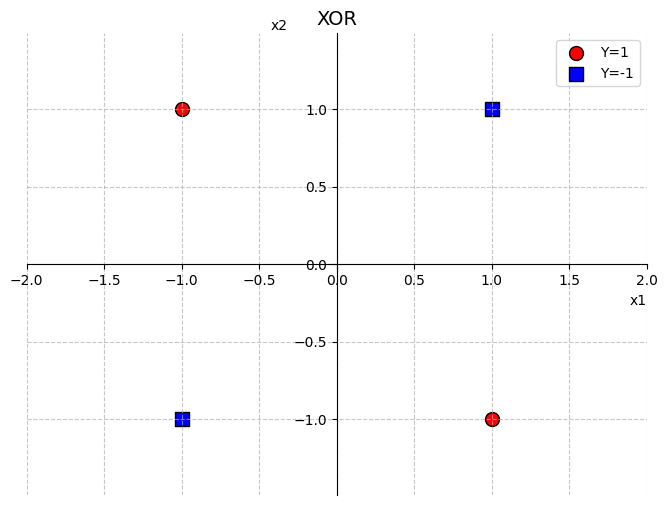

In [57]:
# 获取配置好的fig和ax
fig, ax = get_fig_ax()
plt.title('XOR', fontsize=14)
X = [(1,1), (-1,1),(-1,-1),(1,-1)]
Y = [-1,1,-1,1]
X_array = np.array(X)
x_coords = X_array[:, 0]  # 提取所有点的x坐标
y_coords = X_array[:, 1]  # 提取所有点的y坐标

mask_neg = np.array(Y) == 1
ax.scatter(x_coords[mask_neg], y_coords[mask_neg], 
            color='red', marker='o', s=100, label='Y=1', edgecolors='black')

mask_pos = np.array(Y) == -1
ax.scatter(x_coords[mask_pos], y_coords[mask_pos], 
            color='blue', marker='s', s=100, label='Y=-1', edgecolors='black')
plt.legend(fontsize=10)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


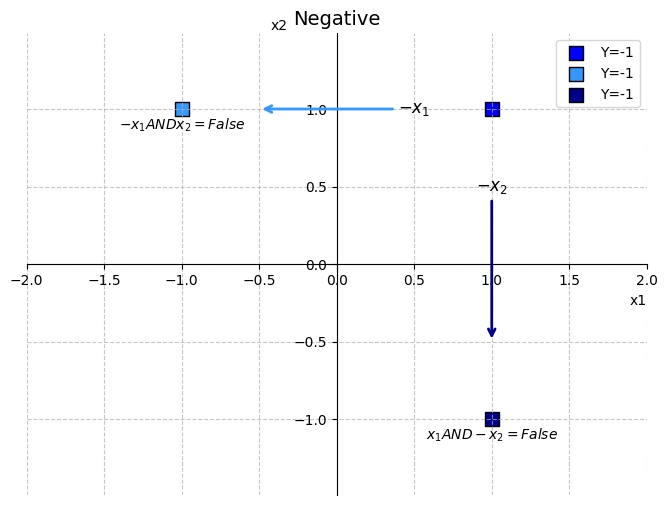

In [139]:
# 获取配置好的fig和ax
fig, ax = get_fig_ax()
plt.title('Negative', fontsize=14)

ax.scatter(1, 1, color='#0000FF', marker='s', s=100, label='Y=-1', edgecolors='black')
ax.scatter(-1, 1, color='#3399FF', marker='s', s=100, label='Y=-1', edgecolors='black')
ax.scatter(1, -1, color='#00008B', marker='s', s=100, label='Y=-1', edgecolors='black')
ax.annotate("$-x_1$", (-0.5, 1), (0.5,1), fontsize=12,   ha="center", va="center",arrowprops=dict(
        arrowstyle='->',  # 引线末端箭头样式
        color='#3399FF',     # 引线颜色
        lw=2              # 引线宽度
    ))
ax.annotate("$-x_2$", (1, -0.5), (1,0.5), fontsize=12,   ha="center", va="center",arrowprops=dict(
        arrowstyle='->',  # 引线末端箭头样式
        color='#00008B',     # 引线颜色
        lw=2              # 引线宽度
    ))
ax.text(-1, 0.9, "$-x_1 AND x_2 = False$",ha="center", va="center" )
ax.text(1, -1.1, "$x_1 AND -x_2 = False$",ha="center", va="center" )

plt.legend(fontsize=10)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


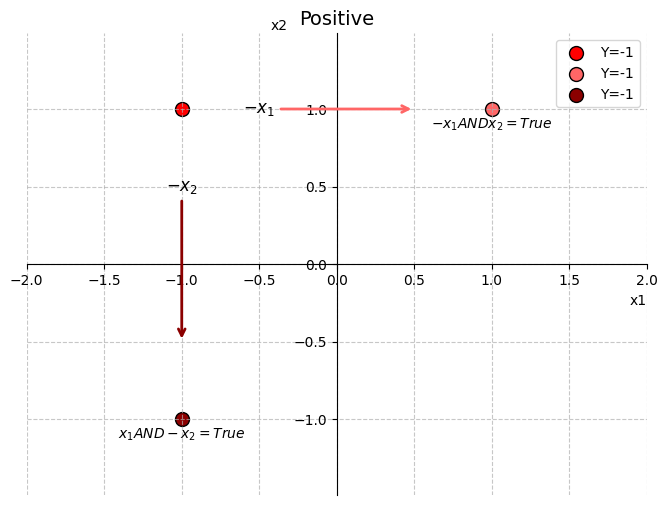

In [146]:
# 获取配置好的fig和ax
fig, ax = get_fig_ax()
plt.title('Positive', fontsize=14)

ax.scatter(-1, 1, color='#FF0000', marker='o', s=100, label='Y=-1', edgecolors='black')
ax.scatter(1, 1, color='#FF6666', marker='o', s=100, label='Y=-1', edgecolors='black')
ax.scatter(-1, -1, color='#8B0000', marker='o', s=100, label='Y=-1', edgecolors='black')
ax.annotate("$-x_1$", (0.5, 1), (-0.5,1), fontsize=12,   ha="center", va="center",arrowprops=dict(
        arrowstyle='->',  # 引线末端箭头样式
        color='#FF6666',     # 引线颜色
        lw=2              # 引线宽度
    ))
ax.annotate("$-x_2$", (-1, -0.5), (-1,0.5), fontsize=12,   ha="center", va="center",arrowprops=dict(
        arrowstyle='->',  # 引线末端箭头样式
        color='#8B0000',     # 引线颜色
        lw=2              # 引线宽度
    ))

ax.text(1, 0.9, "$-x_1 AND x_2 = True$",ha="center", va="center" )
ax.text(-1, -1.1, "$x_1 AND -x_2 = True$",ha="center", va="center" )

plt.legend(fontsize=10)
plt.show()

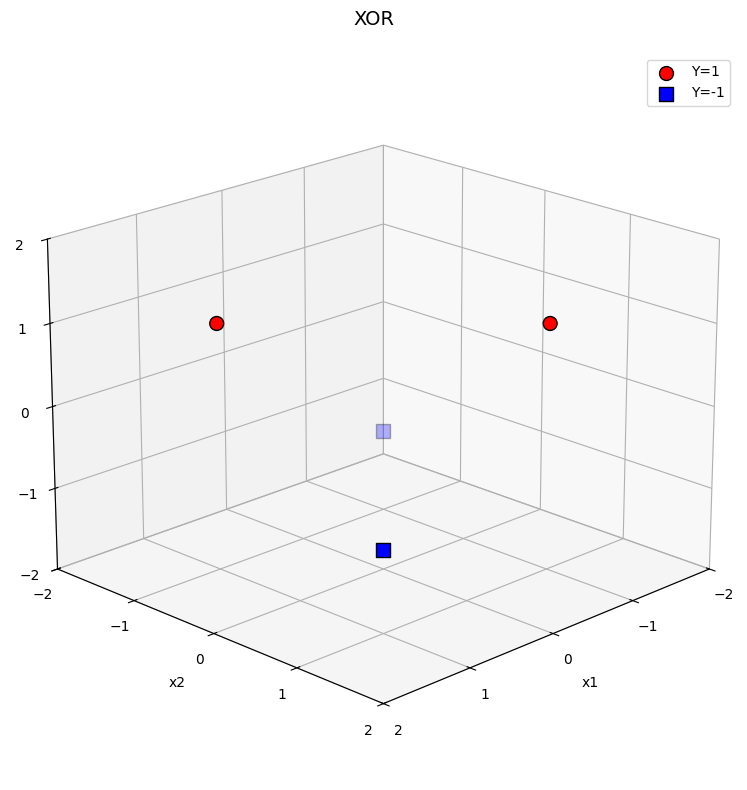

In [145]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # 导入3D绘图必备模块

# 定义3D绘图配置函数，返回配置好的fig和3D ax
def get_3d_fig_ax(figsize=(8, 6)):
    # 创建新的画布
    fig = plt.figure(figsize=figsize)
    # 创建3D坐标轴（核心修改：添加projection='3d'）
    ax = fig.add_subplot(projection='3d')
    
    # 公共样式配置
    ax.grid(True, linestyle='--', alpha=0.7)  # 3D网格：虚线、透明度0.7
    
    # 设置三个轴的显示范围
    ax.set_xlim(-2, 2)  # x1轴范围
    ax.set_ylim(-2, 2)  # x2轴范围
    ax.set_zlim(-2, 2)  # Z轴（Y标签）范围
    
    # 设置坐标轴标签（适配3D）
    ax.set_xlabel("x1", fontsize=10, labelpad=8)
    ax.set_ylabel("x2", fontsize=10, labelpad=8)
    ax.set_zlabel("Y (Z值)", fontsize=10, labelpad=8)
    
    # 设置刻度
    ax.set_xticks(np.arange(-2, 3, 1))
    ax.set_yticks(np.arange(-2, 3, 1))
    ax.set_zticks(np.arange(-2, 3, 1))
    
    return fig, ax

# 获取3D配置好的fig和ax
fig, ax = get_3d_fig_ax(figsize=(10, 8))
plt.title('XOR', fontsize=14, pad=20)

# 原始数据
X = [(1,1), (-1,1),(-1,-1),(1,-1)]  # (x1, x2)
Y = [-1,1,-1,1]                      # 作为Z轴值

# 转换为numpy数组方便索引
X_array = np.array(X)
x1_coords = X_array[:, 0]  # X轴：第一个特征
x2_coords = X_array[:, 1]  # Y轴：第二个特征
z_coords = np.array(Y)     # Z轴：标签Y

# 绘制3D散点图（核心修改：增加z轴参数）
# Y=1的点：红色圆形
mask_1 = z_coords == 1
ax.scatter(x1_coords[mask_1], x2_coords[mask_1], z_coords[mask_1],
            color='red', marker='o', s=100, label='Y=1', edgecolors='black')

# Y=-1的点：蓝色方形
mask_neg1 = z_coords == -1
ax.scatter(x1_coords[mask_neg1], x2_coords[mask_neg1], z_coords[mask_neg1],
            color='blue', marker='s', s=100, label='Y=-1', edgecolors='black')

# 添加图例和调整视角（可选：可以拖动鼠标旋转3D视角）
ax.legend(fontsize=10, loc='upper right')
# 设置初始视角（azim是方位角，elev是仰角）
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## 3. 单隐藏层神经网络

### 1.3 神经网络的隐藏层

#### 1. 基础逻辑门的感知器实现

符号函数（Sign Function）：

$$
sign(x) = \begin{cases}
1, & \text{if } x > 0 \\
-1, & \text{if } x \leq 0
\end{cases}
$$

- 与门：$y = sign(x_1+x_2-1)$
- 或门：$y = sign(x_1+x_2+1)$
- 非门：$y = -x_1$

---

也可以不加偏置，与门使用step激活函数：
$$
step(x) = \begin{cases}
1, & \text{if } x \gt 0 \\
0, & \text{if } x \leq 0
\end{cases}
$$

或门使用修改后的step激活函数：
$$
step(x) = \begin{cases}
1, & \text{if } x \geq 0 \\
0, & \text{if } x \lt 0
\end{cases}
$$

在神经网络计算过程中，不可能通过人工辨别与运算或运算，来设置step的边界，因此还是加上偏置合适。



#### 2. 异或门的神经网络实现


$$
z_{11} = x_{11}+x_{12}-1   \\ 
a_{11} = sign(z_{11}) \\ 
z_{12} = x_{11}+x_{12}-1  \\ 
a_{12} = sign(z_{12}) \\ 
z_{2} = a_{11} + a_{12} + 1  \\ 
a_2 = sign(z_{2})
$$



```mermaid
graph LR
    %% 初始化 MathJax
    %%{init: {'mathjax': 'https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js'}}%%
    X11(("$$X_{1}$$")) --> z11(("$$z_{11}$$"))
    W11(("$$W_{11}$$")) --$$\frac{\partial{z_{11}}}{\partial{W_{11}}}=X_{1}$$--> z11
    
    X12(("$$X_{1}$$")) --> z12(("$$z_{11}$$"))
    W12(("$$W_{12}$$")) --> z12
    
    z11(("$$z_{11}$$")) --"a'"--> a11(("$$a_{11}$$"))
    z12(("$$z_{12}$$")) --> a12(("$$a_{12}$$"))
    
    a11(("$$a_{11}$$")) --> X21(("$$X_{2}$$"))
    a12(("$$a_{12}$$")) --> X21(("$$X_{2}$$"))

    X21(("$$X_{2}$$")) --$$\frac{\partial{z_{2}}}{\partial{X_{2}}}=W_{2}$$--> z21(("$$z_{21}$$"))
    W21(("$$W_{2}$$")) --> z21(("$$z_{2}$$"))
    z21(("$$z_{2}$$")) --a'--> a21(("$$a_{2}$$"))
    %% 样式美化
    classDef layer1 fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef layer2 fill:#e8f5e8,stroke:#2e7d32,stroke-width:2px;
    classDef layer3 fill:#f3e5f5,stroke:#4a148c,stroke-width:1px;
    classDef loss fill:#fff3e0,stroke:#e65100,stroke-width:1px;
    
    class X11,X12,X13,X14,W11,W12,W13,W14,z11,z12,z13,z14,a11,a12,a13,a14 layer1;
    class X21,X22,W21,W22,z21,z22,a21,a22 layer2;
	class X31,W31,z31,a31 layer3;
```



> 加法（同维运算）与乘法（升维）
>
> 使用基础门电路实现双控开关（异或）
>
> 使用增加一个隐藏层的多层感知器，可以解决异或型数据分类问题。

### 二维异或型数据

### 三维异或型数据

## 4. 浅层神经网络

### 2.1 网络结构

为方便深度链式求导，没有绘制成全连接网络。

#### 前向传播

| 第一层                             | 第二层                                                    | 第三层                                                     | 损失计算                    |
| ---------------------------------- | --------------------------------------------------------- | ---------------------------------------------------------- | --------------------------- |
| $z_{11} = X_{11}W_{11}$            |                                                           |                                                            |                             |
| $a_{11} = \text{activate}(z_{11})$ | $z_{21} = X_{21}W_{21}$$\qquad  (X_{21}=[a_{11},a_{12}])$ |                                                            |                             |
| $z_{12} = X_{12}W_{12}$            | $a_{21} = \text{activate}(z_{21})$                        |                                                            |                             |
| $a_{12} = \text{activate}(z_{12})$ |                                                           | $z_{31} = X_{31}W_{31}$ $\qquad  (X_{31}=[a_{21},a_{22}])$ |                             |
|                                    |                                                           | $a_{31} = \text{activate}(z_{31})$                         | $L=\frac{1}{2}(y-a_{31})^2$ |
| $z_{13} = X_{13}W_{13}$            |                                                           |                                                            |                             |
| $a_{13} = \text{activate}(z_{13})$ | $z_{22} = X_{22}W_{22}$$\qquad  (X_{22}=[a_{13},a_{14}])$ |                                                            |                             |
| $z_{14} = X_{14}W_{14}$            | $a_{22} = \text{activate}(z_{22})$                        |                                                            |                             |
| $a_{14} = \text{activate}(z_{14})$ |                                                           |                                                            |                             |

#### 反向传播

| 第一层                | 第二层                | 第三层 | 损失计算 |
|-----------------------------|-----------------------------|-----------------------------|-----------------------------|
| $z_{11} = X_{11}W_{11}$  $\frac{ \partial{ z_{11} }}{ \partial{ W_{11} }} = X_{11}$ |        |        |        |
| $a_{11} = \text{activate}(z_{11})$ $\frac{ \partial{ a_{11} }}{ \partial{ z_{11} }} = a_{11}'$ | $z_{21} = X_{21}W_{21}$ $\frac{ \partial{ z_{21} }}{ \partial{ X_{21} }} = W_{21}$ |  |  |
| $z_{12} = X_{12}W_{12}$ | $a_{21} = \text{activate}(z_{21})$ $\frac{ \partial{ a_{21} }}{ \partial{ z_{21} }} = a_{21}'$ |  |  |
| $a_{12} = \text{activate}(z_{12})$ | $\qquad\qquad\qquad  (X_{21}=[a_{11},a_{12}])$ | $z_{31} = X_{31}W_{31}$ $\frac{ \partial{ z_{31} }}{ \partial{ X_{31} }} = W_{31}$ | $L=\frac{1}{2}(y-a_{31})^2$ $\frac{ \partial{ L }}{ \partial{ a_{31} }} = a_{31}-y$ |
|  |  | $a_{31} = \text{activate}(z_{31})$ $\frac{ \partial{ a_{31} }}{ \partial{ z_{31} }} = a_{31}'$ |  |
| $z_{13} = X_{13}W_{13}$ |        | $\qquad\qquad\qquad  (X_{22}=[a_{21},a_{22}])$ |        |
| $a_{13} = \text{activate}(z_{13})$ | $z_{22} = X_{22}W_{22}$ |  |  |
| $z_{14} = X_{14}W_{14}$ | $a_{22} = \text{activate}(z_{22})$ |  |  |
| $a_{14} = \text{activate}(z_{14})$ | $\qquad\qquad\qquad  (X_{22}=[a_{13},a_{14}])$ |  |  |

#### 非全连接版

```mermaid
graph LR
    %% 初始化 MathJax
    %%{init: {'mathjax': 'https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js'}}%%

    X11(("$$X_{11}$$")) --> z11(("$$z_{11}$$"))
    W11(("$$W_{11}$$")) --$$\frac{\partial{z_{11}}}{\partial{W_{11}}}=X_{11}$$--> z11
    
    X12(("$$X_{12}$$")) --> z12(("$$z_{11}$$"))
    W12(("$$W_{12}$$")) --> z12
    
    z11(("$$z_{11}$$")) --"a'"--> a11(("$$a_{11}$$"))
    z12(("$$z_{12}$$")) --> a12(("$$a_{12}$$"))
    
    a11(("$$a_{11}$$")) --> X21(("$$X_{21}$$"))
    a12(("$$a_{12}$$")) --> X21(("$$X_{21}$$"))
    
    
    X13(("$$X_{13}$$")) --> z13(("$$z_{13}$$"))
    W13(("$$W_{13}$$")) --> z13(("$$z_{13}$$"))
    
    X14(("$$X_{14}$$")) --> z14(("$$z_{14}$$"))
    W14(("$$W_{14}$$")) --> z14(("$$z_{14}$$"))
    
    z13(("$$z_{14}$$")) --> a13(("$$a_{13}$$"))
    z14(("$$z_{14}$$")) --> a14(("$$a_{14}$$"))
    
    a13(("$$a_{13}$$")) --> X22(("$$X_{22}$$"))
    a14(("$$a_{14}$$")) --> X22(("$$X_{22}$$"))
    
    X21(("$$X_{21}$$")) --$$\frac{\partial{z_{21}}}{\partial{X_{21}}}=W_{21}$$--> z21(("$$z_{21}$$"))
    X22(("$$X_{22}$$")) --> z22(("$$z_{22}$$"))
    W21(("$$W_{21}$$")) --> z21(("$$z_{21}$$"))
    W22(("$$W_{22}$$")) --> z22(("$$z_{22}$$"))
    z21(("$$z_{21}$$")) --a'--> a21(("$$a_{21}$$"))
    z22(("$$z_{22}$$")) --> a22(("$$a_{22}$$"))
    
    a21(("$$a_{21}$$")) --> X31(("$$X_{31}$$"))
    a22(("$$a_{22}$$")) --> X31(("$$X_{31}$$"))
    
    X31(("$$X_{31}$$")) --$$\frac{\partial{z_{31}}}{\partial{X_{31}}}=W_{31}$$--> z31(("$$z_{31}$$"))
    W31(("$$W_{31}$$")) --> z31(("$$z_{31}$$"))
    z31(("$$z_{31}$$")) --a'--> a31(("$$a_{31}$$"))
    
    a31(("$$a_{31}$$"))--$$\frac{\partial{L}}{\partial{a_{31}}}=a_{31}-Y$$--> L(("$$L$$"))
    Y(("$$Y$$")) --> L(("$$L$$"))
    
    %% 样式美化
    classDef layer1 fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef layer2 fill:#e8f5e8,stroke:#2e7d32,stroke-width:2px;
    classDef layer3 fill:#f3e5f5,stroke:#4a148c,stroke-width:1px;
    classDef loss fill:#fff3e0,stroke:#e65100,stroke-width:1px;
    
    class X11,X12,X13,X14,W11,W12,W13,W14,z11,z12,z13,z14,a11,a12,a13,a14 layer1;
    class X21,X22,W21,W22,z21,z22,a21,a22 layer2;
	class X31,W31,z31,a31 layer3;
```



---

#### 全连接版

```mermaid
graph LR
    %% 初始化 MathJax
    %%{init: {'mathjax': 'https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js'}}%%

    X11(("$$X_{11}$$")) --> z11(("$$z_{11}$$"))
    W11(("$$W_{11}$$")) --$$\frac{\partial{z_{11}}}{\partial{W_{11}}}=X_{11}$$--> z11
    
    X12(("$$X_{12}$$")) --> z12(("$$z_{11}$$"))
    W12(("$$W_{12}$$")) --> z12
    
    z11(("$$z_{11}$$")) --"a'"--> a11(("$$a_{11}$$"))
    z12(("$$z_{12}$$")) --> a12(("$$a_{12}$$"))
    
    a11(("$$a_{11}$$")) --> X21(("$$X_{21}$$"))
    a12(("$$a_{12}$$")) --> X21(("$$X_{21}$$"))
    
    
    X13(("$$X_{11}$$")) --> z13(("$$z_{11}$$"))
    W13(("$$W_{11}$$")) --> z13(("$$z_{11}$$"))
    
    X14(("$$X_{12}$$")) --> z14(("$$z_{12}$$"))
    W14(("$$W_{12}$$")) --> z14(("$$z_{12}$$"))
    
    z13(("$$z_{11}$$")) --> a13(("$$a_{11}$$"))
    z14(("$$z_{12}$$")) --> a14(("$$a_{12}$$"))
    
    a13(("$$a_{11}$$")) --> X22(("$$X_{22}$$"))
    a14(("$$a_{12}$$")) --> X22(("$$X_{22}$$"))
    
    X21(("$$X_{21}$$")) --$$\frac{\partial{z_{21}}}{\partial{X_{21}}}=W_{21}$$--> z21(("$$z_{21}$$"))
    X22(("$$X_{22}$$")) --> z22(("$$z_{22}$$"))
    W21(("$$W_{21}$$")) --> z21(("$$z_{21}$$"))
    W22(("$$W_{22}$$")) --> z22(("$$z_{22}$$"))
    z21(("$$z_{21}$$")) --a'--> a21(("$$a_{21}$$"))
    z22(("$$z_{22}$$")) --> a22(("$$a_{22}$$"))
    
    a21(("$$a_{21}$$")) --> X31(("$$X_{31}$$"))
    a22(("$$a_{22}$$")) --> X31(("$$X_{31}$$"))
    
    X31(("$$X_{31}$$")) --$$\frac{\partial{z_{31}}}{\partial{X_{31}}}=W_{31}$$--> z31(("$$z_{31}$$"))
    W31(("$$W_{31}$$")) --> z31(("$$z_{31}$$"))
    z31(("$$z_{31}$$")) --a'--> a31(("$$a_{31}$$"))
    
    a31(("$$a_{31}$$"))--$$\frac{\partial{L}}{\partial{a_{31}}}=a_{31}-Y$$--> L(("$$L$$"))
    Y(("$$Y$$")) --> L(("$$L$$"))
    
    %% 样式美化
    classDef layer1 fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef layer2 fill:#e8f5e8,stroke:#2e7d32,stroke-width:2px;
    classDef layer3 fill:#f3e5f5,stroke:#4a148c,stroke-width:1px;
    classDef loss fill:#fff3e0,stroke:#e65100,stroke-width:1px;
    
    class X11,X12,X13,X14,W11,W12,W13,W14,z11,z12,z13,z14,a11,a12,a13,a14 layer1;
    class X21,X22,W21,W22,z21,z22,a21,a22 layer2;
	class X31,W31,z31,a31 layer3;
```

#### 链式求导

$$
\frac{\partial L}{\partial W_{11}} = \frac{\partial L}{\partial a_{31}} \frac{\partial a_{31}}{\partial z_{31}} \frac{\partial z_{31}}{\partial a_{21}} \frac{\partial a_{21}}{\partial z_{21}}\frac{\partial z_{21}}{\partial a_{11}} \frac{\partial a_{11}}{\partial z_{z1}} \frac{\partial z_{11}}{\partial W_{11}}=(a_{31}-y)a'_{31}W_{31}a'_{21}W_{21}a'_{11}X_{11}
$$



##### 链式求导的数学本质

根据链式求导公式：
$$
\frac{\partial L}{\partial W_{11}} = (a_{31}-y) \cdot a'_{31} \cdot W_{31} \cdot a'_{21} \cdot W_{21} \cdot a'_{11} \cdot X_{11}
$$
可得出以下结论：

- **核心要素**：梯度由 **误差项**（\(a_{31}-y\)）、**激活函数导数链**（\(a'_{31} \cdot a'_{21} \cdot a'_{11}\)）、**权重矩阵链**（\(W_{31} \cdot W_{21}\)）和 **输入信号**（\(X_{11}\)）共同决定。
- **乘积效应**：梯度是多个因子的连乘积，任何一个因子的极端值（趋近0或无穷大）都会主导梯度的最终结果。

#### 常见激活函数

![](./assets/4-activation-sigmoid.png)

![](./assets/4-activation-tanh.png)

![](./assets/4-activation-relu.png)

```mermaid
timeline
    title 神经网络关键技术发展时间线（修订版）
    section 诞生与早期探索
        1943年 : 阈值激活函数(阶跃)
        1958年 : 感知机(阶跃函数)
    section 发展中的困境与突破
        1970s : Sigmoid激活函数
        1980s : tanh激活函数
        1986年 : 反向传播复兴
    section 深度学习困境
        1990s : 基础权重初始化
        1990s : 梯度裁剪(RNN)
    section 深度学习革命
        2006年 : 分层预训练
        2010年 : Xavier初始化
        2011年 : ReLU普及
        2015年 : 批量归一化<br>He初始化
```

### 2.2 梯度消失

#### 出现原因

##### **激活函数导数衰减**

以**sigmoid**函数为例，其导数范围为\(0 < \sigma'(z) \leq 0.25\)。若每层激活函数均使用sigmoid，梯度会逐层乘以小于0.25的系数。

##### **权重矩阵的收缩效应**

若权重初始化值较小（如\(W_{21}, W_{31} \in (0,1)\)），梯度会进一步被压缩。

#### **量化示例**

假设：

- \(a_{31}-y = 1\)（单位误差）
- \(a'_{31} = a'_{21} = a'_{11} = 0.25\)（sigmoid导数）
- \(W_{31} = W_{21} = 0.5\)（小权重）
- \(X_{11} = 1\)（单位输入）

则梯度计算为：
$$
\frac{\partial L}{\partial W_{11}} = 1 \cdot 0.25 \cdot 0.5 \cdot 0.25 \cdot 0.5 \cdot 0.25 \cdot 1 = 0.25^3 \cdot 0.5^2 = 0.00195
$$
经过3层链式乘积后，梯度衰减至初始值的0.195%。

#### **实际影响**

- **浅层权重冻结**：靠近输入层的权重（如\(W_{11}\)）更新缓慢，导致网络无法有效提取底层特征。
- **模型退化**：深层网络退化为浅层网络，无法学习复杂模式。

#### **解决方案**

- **激活函数替换**：使用ReLU系列函数（ReLU、Leaky ReLU），其导数在正区间为1，避免梯度衰减。

- **权重初始化优化**：Xavier初始化（针对sigmoid），He初始化（针对ReLU），确保梯度方差稳定。




---

### 2.3 Xavier初始化

Xavier初始化（Glorot初始化）的理论依据源于2010年Glorot和Bengio在论文《Understanding the Difficulty of Training Deep Feedforward Neural Networks》中提出的**方差守恒原则**。其核心目标是通过动态调整权重范围，确保信号在前向传播和反向传播过程中的方差保持稳定，从而避免梯度消失或爆炸问题。以下从数学推导、核心假设和激活函数适配三个维度展开说明：

#### 1. 数学推导：方差守恒的核心逻辑
Xavier初始化的推导基于以下两个关键假设：
1. **激活函数在0点附近近似线性**（如tanh、sigmoid）。
2. **权重与输入信号相互独立且均值为0**。

##### 1. 前向传播的方差约束
假设某层输入为 $ \mathbf{x} $（方差为 $ \sigma_x^2 $），权重矩阵为 $ \mathbf{W} $（方差为 $ \sigma_w^2 $），输出为 $ \mathbf{z} = \mathbf{x} \mathbf{W} $。若激活函数为线性（或近似线性），则输出方差为：
$$
\sigma_z^2 = n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma_x^2
$$
为使输出方差与输入方差一致（$ \sigma_z^2 = \sigma_x^2 $），需满足：
$$
\sigma_w^2 = \frac{1}{n_{\text{in}}}
$$

##### 2. 反向传播的梯度方差约束
反向传播时，梯度 $\delta$ 的传播公式为 $\delta^{(l-1)} = \delta^{(l)} \mathbf{W}^{(l)T} \cdot f'(\mathbf{z}^{(l)})$。假设激活函数导数 $f'(\mathbf{z})$ 的均值为1（如tanh在0点导数为1），则梯度方差为：
$$
\sigma_{\delta^{(l-1)}}^2 = n_{\text{out}} \cdot \sigma_w^2 \cdot \sigma_{\delta^{(l)}}^2
$$
为保持梯度方差稳定（$\sigma_{\delta^{(l-1)}}^2 = \sigma_{\delta^{(l)}}^2$），需满足：
$$
\sigma_w^2 = \frac{1}{n_{\text{out}}}
$$

##### 3. 综合前向与反向约束
为同时满足前向和反向传播的方差要求，Xavier取调和平均值：
$$
\sigma_w^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}
$$
对应均匀分布范围为：
$$
W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}, \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}\right)
$$
正态分布形式为：
$$
W \sim N\left(0, \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}\right)
$$

#### 2. 双隐层网络中的具体应用
以用户提供的双隐层网络为例（图1），Xavier初始化需逐层计算各权重矩阵的初始化范围：
1. **第一层（输入层→隐藏层1）**：
   - 输入维度 $ n_{\text{in}} = 1 $（假设输入为单个特征 $ X_1 $），输出维度 $ n_{\text{out}} = 4 $（隐藏层1有4个神经元）。
   - 均匀分布范围：$U\left(-\sqrt{\frac{6}{1+4}}, \sqrt{\frac{6}{1+4}}\right) \approx U(-1.095, 1.095)$。
2. **第二层（隐藏层1→隐藏层2）**：
   - 输入维度 $n_{\text{in}} = 4$，输出维度 $n_{\text{out}} = 2$（隐藏层2有2个神经元）。
   - 均匀分布范围：$U\left(-\sqrt{\frac{6}{4+2}}, \sqrt{\frac{6}{4+2}}\right) \approx U(-1.0, 1.0)$。
3. **第三层（隐藏层2→输出层）**：
   - 输入维度 $n_{\text{in}} = 2$，输出维度 $n_{\text{out}} = 1$。
   - 均匀分布范围：$U\left(-\sqrt{\frac{6}{2+1}}, \sqrt{\frac{6}{2+1}}\right) \approx U(-1.414, 1.414)$。





---

### 2.4 He初始化

He初始化（Kaiming初始化）是2015年由何恺明团队提出的权重初始化方法，专门针对ReLU激活函数的特性设计，通过动态调整权重范围确保信号在深层网络中稳定传播。其核心优势在于解决ReLU的“神经元死亡”问题，并显著提升深层网络的训练效率。以下从理论推导、实现细节、适用场景及工程实践等方面展开说明：

#### 1. 理论依据：补偿ReLU的非线性特性
ReLU激活函数在输入为负时输出为0，导致前向传播时信号方差减半，反向传播时梯度仅在正区间有效。He初始化通过以下数学推导补偿这一特性：

##### 1. 前向传播的方差约束
假设输入 $\mathbf{x}$ 的方差为 $\sigma_x^2$，权重矩阵 $\mathbf{W}$ 的方差为 $\sigma_w^2$，则线性变换后的输出方差为：
$$
\sigma_z^2 = n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma_x^2
$$
应用ReLU后，输出方差因一半神经元被置零而减半：
$$
\sigma_a^2 = \frac{1}{2} \cdot n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma_x^2
$$
为保持 $\sigma_a^2 = \sigma_x^2$，需满足：
$$
\sigma_w^2 = \frac{2}{n_{\text{in}}}
$$

##### 2. 反向传播的梯度约束
ReLU的导数在正区间为1，负区间为0，导致梯度方差同样减半。He初始化通过增大权重方差补偿这一衰减，确保梯度在反向传播时稳定传递。最终推导得到权重标准差为：
$$
\sigma = \sqrt{\frac{2}{n_{\text{in}}}}
$$

##### 3. 分布形式
- **正态分布**：$W \sim N\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$
- **均匀分布**：$W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}}}}, \sqrt{\frac{6}{n_{\text{in}}}}\right)$

#### 2. 实现细节：逐层适配ReLU特性
以双隐层网络为例，He初始化的具体应用步骤如下：

##### 1. 输入层→隐藏层1

- 输入维度 $n_{\text{in}} = 1$，输出维度 $n_{\text{out}} = 4$
- 均匀分布范围：$U\left(-\sqrt{\frac{6}{1}}, \sqrt{\frac{6}{1}}\right) \approx U(-2.45, 2.45)$

##### 2. 隐藏层1→隐藏层2
- 输入维度 $n_{\text{in}} = 4$，输出维度 $n_{\text{out}} = 2$
- 均匀分布范围：$U\left(-\sqrt{\frac{6}{4}}, \sqrt{\frac{6}{4}}\right) \approx U(-1.22, 1.22)$

##### 3. 隐藏层2→输出层
- 输入维度 $n_{\text{in}} = 2$，输出维度 $n_{\text{out}} = 1$
- 均匀分布范围：$U\left(-\sqrt{\frac{6}{2}}, \sqrt{\frac{6}{2}}\right) \approx U(-1.73, 1.73)$

##### 4. 偏置项处理
- 偏置项通常初始化为0，因为其对梯度方差影响较小



#### 3. 与Xavier初始化的对比
| 维度         | Xavier初始化                          | He初始化                              |
|--------------|-------------------------------------|-------------------------------------|
| **理论依据**   | 平衡前向/反向方差，适用于线性激活函数      | 补偿ReLU的半激活特性，保持方差稳定      |
| **方差公式**   | $\sigma^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}$ | $\sigma^2 = \frac{2}{n_{\text{in}}}$ |
| **适用激活函数** | tanh/sigmoid等对称函数                 | ReLU/Leaky ReLU等非对称函数            |
| **深层网络表现** | 梯度消失风险较高                       | 有效抑制梯度消失，收敛速度提升30%以上 |
| **工程实践**   | 需结合BatchNorm优化                    | 可独立使用，与残差连接兼容性更佳         |



### 2.5 梯度爆炸

##### **激活函数导数放大**

激活函数在某些区域导数大于等于1（以ReLU激活函数为例，正半轴导数恒为1），可能加剧梯度放大。

##### **权重矩阵的扩张效应**

若权重初始化值较大（如\(W_{21}, W_{31} > 1\)），梯度会逐层乘以大于1的系数。

##### **量化示例**

假设：

- \(a_{31}-y = 1\)
- \(a'_{31} = a'_{21} = a'_{11} = 1\)（ReLU导数）
- \(W_{31} = W_{21} = 2\)（大权重）
- \(X_{11} = 1\)

则梯度计算为：
$$
\frac{\partial L}{\partial W_{11}} = 1 \cdot 1 \cdot 2 \cdot 1 \cdot 2 \cdot 1 \cdot 1 = 2^2 = 4
$$
经过2层权重矩阵乘积后，梯度放大至初始值的4倍。

##### **实际影响**

- **参数更新失控**：权重值剧烈波动，可能导致模型发散（如出现NaN）。
- **数值稳定性问题**：超出浮点数表示范围，引发计算错误。

##### **解决方案**

- **梯度裁剪**：设置阈值（如5），当梯度超过阈值时进行截断。
- **权重正则化**：添加L2正则项（\(\lambda \sum W^2\)），惩罚过大的权重。
- **Batch Normalization**：对每层输入进行标准化，减少内部协变量偏移，稳定梯度传播。



### 2.6 对比分析与总结

| 问题类型   | 核心成因                          | 关键因子                 | 典型现象                     | 解决方案                          |
|------------|-----------------------------------|--------------------------|------------------------------|-----------------------------------|
| 梯度消失   | 激活函数导数连乘衰减+小权重      | \(a' \cdot W < 1\)       | 浅层权重更新停滞            | ReLU激活、He初始化、残差连接     |
| 梯度爆炸   | 大权重连乘+激活函数导数放大      | \(a' \cdot W > 1\)       | 参数剧烈震荡、NaN出现        | 梯度裁剪、L2正则、Batch Normalization |

### 2.7 特殊场景讨论

**1. 双隐层网络的特殊性**

- **层数较少**：相对于深层网络，双隐层的梯度消失/爆炸风险较低，但仍可能因激活函数选择或权重初始化不当而发生。
- **结构对称性**：若两个隐藏层的神经元数量相同且激活函数一致，梯度传播路径对称，可能加剧梯度问题。

**2. ReLU的局限性**

- **Dead ReLU问题**：若输入始终为负，ReLU导数为0，导致对应神经元无法激活。可通过Leaky ReLU或小学习率缓解。
- **梯度爆炸风险**：ReLU导数为1时，若权重过大，梯度可能直接放大。

**3. 混合激活函数策略**
- **隐藏层用ReLU**：缓解梯度消失。
- **输出层用sigmoid/softmax**：适用于分类任务，但需注意输出层导数对梯度的影响。

## 3. 深度神经网络

### 残差连接

---

**i 是输入向量的维度索引，j 是输出向量的维度索引**。

### 具体含义拆解
- **i 的作用**：对应输入 $\mathbf{x}$ 的每个维度，取值范围是 $1$ 到 $n_{\text{in}}$（输入维度数）。比如 $x_i$ 就是输入向量的第 $i$ 个元素，$W_{ji}$ 是权重矩阵中“连接输入第 $i$ 维到输出第 $j$ 维”的元素。
- **j 的作用**：对应输出 $\mathbf{z}$ 的每个维度，取值没有明确限制（由权重矩阵的列数决定）。比如 $z_j$ 就是输出向量的第 $j$ 个元素，每个 $z_j$ 都由所有输入维度 $x_i$ 加权求和得到。

### 与公式的对应关系
- 公式 $z_j = \sum_{i=1}^{n_{\text{in}}} W_{ji} x_i$ 表示：输出的第 $j$ 个元素，是输入所有 $n_{\text{in}}$ 个维度（每个 $x_i$），分别乘以对应的权重 $W_{ji}$ 后求和的结果。
- 推导中对 $i$ 求和，是因为每个输出维度都依赖全部输入维度；而 $j$ 是固定的，代表我们正在计算某个特定输出维度的方差。

## 推导过程

### 基本假设
1. **权重独立性**：权重 $W_{ij}$ 是独立同分布的随机变量
2. **输入独立性**：输入 $x_i$ 是独立同分布的随机变量  
3. **权重与输入独立**：$W_{ij}$ 与 $x_i$ 相互独立
4. **零均值**：$E[W_{ij}] = 0$，$E[x_i] = 0$

### 数学推导

考虑线性变换：$z_j = \sum_{i=1}^{n_{\text{in}}} W_{ji} x_i$

**步骤1：计算 $z_j$ 的期望值**
由于权重和输入的期望都为0：
$$
E[z_j] = E\left[\sum_{i=1}^{n_{\text{in}}} W_{ji} x_i\right] = \sum_{i=1}^{n_{\text{in}}} E[W_{ji}] E[x_i] = 0
$$

$$
z_j=x_1w_{11}+x_2w_{12}+x_3w_{13} \\
E(z_j)=E(x_1w_{11}+x_2w_{12}+x_3w_{13}) =E(x_1w_{11})+E(x_2w_{12})+E(x_3w_{13}) \\
E(x_1)E(w_{11})+E(x_2)E(w_{12})+E(x_3)E(w_{13})
$$

**步骤2：计算 $z_j$ 的方差**
根据方差定义：
$$
\text{Var}(z_j) = E[z_j^2] - (E[z_j])^2 = E[z_j^2]
$$


展开平方项：
$$
E[z_j^2] = E\left[\left(\sum_{i=1}^{n_{\text{in}}} W_{ji} x_i\right)^2\right] = E\left[\sum_{i=1}^{n_{\text{in}}} \sum_{k=1}^{n_{\text{in}}} W_{ji} W_{jk} x_i x_k\right]
$$
**步骤3：利用独立性简化**
由于 $W_{ji}$ 和 $x_i$ 相互独立，且不同索引的权重/输入也相互独立：

- 当 $i \neq k$ 时：$E[W_{ji}W_{jk}x_ix_k] = E[W_{ji}]E[W_{jk}]E[x_i]E[x_k] = 0$
- 当 $i = k$ 时：$E[W_{ji}^2 x_i^2] = E[W_{ji}^2] E[x_i^2] = \sigma_w^2 \sigma_x^2$

**步骤4：得到最终结果**
$$\text{Var}(z_j) = \sum_{i=1}^{n_{\text{in}}} \sigma_w^2 \sigma_x^2 = n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma_x^2$$

因此：
$$\sigma_z^2 = n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma_x^2$$

### 直观理解

这个公式表明：
- **输出方差** = **输入节点数** × **权重方差** × **输入方差**
- 每个输入-权重乘积项贡献 $\sigma_w^2 \sigma_x^2$ 的方差
- 由于有 $n_{\text{in}}$ 个这样的独立项，总方差是它们的和

### 在He初始化中的意义

这个推导是He初始化的理论基础。通过控制权重方差 $\sigma_w^2 = \frac{2}{n_{\text{in}}}$，可以确保经过ReLU激活后信号方差保持不变，从而解决梯度消失/爆炸问题。

这个方差传播的分析方法也适用于其他初始化策略（如Xavier初始化），是理解深度神经网络训练稳定性的关键洞见。



